# IMPORTANT

Two notebooks still reference the old 
select_ensemble_hashes_by_metadata_filter
 API:

compare_diversity.ipynb
polar_pairwise_diversity.ipynb
These would need 
select_ensemble_hashes_by_metadata_filter(save_dir, fn)
 replaced with:

python
select_ensembles(save_dir, filter_fn=fn)
The new API returns full info dicts instead of hashes, so downstream code accessing the results may also need adjustment.

This notebook replicates the analysis from the pairwise diversity notebook, but instead of using nested dicts, it incrementally builds a Polars DataFrame, adding columns for each metric and result.

In [ ]:
import sys

sys.path.append("..")
import polars as pl
import utils.ensemble_utils as ens
from configs import env
import utils.run_inference as run
import exp_diversity as exp_div

In [15]:
hashes = ens.select_ensemble_hashes_by_metadata_filter(
    env.ENSEMBLES_ROOT, lambda meta: meta["state"] == "full"
)
print(f"Number of ensembles: {len(hashes)}")

Number of ensembles: 4


Start with a DataFrame containing only the ensemble hashes.

In [16]:
df = pl.DataFrame({"hash": hashes})
df

hash
str
"""2572dd6f862bd42b"""
"""93a692bec0ef4e6d"""
"""5a082d77c912e6e1"""
"""0d9e88ef0fce8ae9"""


Add the 'rho' value for each ensemble.

In [17]:
df = df.with_columns(
    pl.Series(
        "rho", [float(ens.load_metadata(env.ENSEMBLES_ROOT, h)["rho"]) for h in hashes]
    )
)
df

hash,rho
str,f64
"""2572dd6f862bd42b""",0.0
"""93a692bec0ef4e6d""",0.2
"""5a082d77c912e6e1""",0.04
"""0d9e88ef0fce8ae9""",0.008


Add the ensemble accuracy for each hash.

In [18]:
df = df.with_columns(
    pl.Series(
        "accuracy",
        [
            ens.get_ensemble_accuracies(
                ens.load_ensemble(env.ENSEMBLES_ROOT, h), run.get_cifar10_test_labels()
            ).get("soft", None)
            for h in hashes
        ],
    )
)
df

/home/vlr/Workspaces/Topographic/ConTopo/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


hash,rho,accuracy
str,f64,f64
"""2572dd6f862bd42b""",0.0,0.9431
"""93a692bec0ef4e6d""",0.2,0.9443
"""5a082d77c912e6e1""",0.04,0.9448
"""0d9e88ef0fce8ae9""",0.008,0.9413


Add the mean accuracy of the components for each ensemble.

In [19]:
df = df.with_columns(
    pl.Series(
        "comp_mean_acc",
        [
            ens.get_component_accuracies_by_hash(env.ENSEMBLES_ROOT, h).get(
                "comp_mean_acc", None
            )
            for h in hashes
        ],
    )
)
df

hash,rho,accuracy,comp_mean_acc
str,f64,f64,f64
"""2572dd6f862bd42b""",0.0,0.9431,0.91425
"""93a692bec0ef4e6d""",0.2,0.9443,0.91275
"""5a082d77c912e6e1""",0.04,0.9448,0.91474
"""0d9e88ef0fce8ae9""",0.008,0.9413,0.91064


Add the difference between ensemble accuracy and mean component accuracy.

In [20]:
df = df.with_columns((df["accuracy"] - df["comp_mean_acc"]).alias("accuracy_diff"))
df

hash,rho,accuracy,comp_mean_acc,accuracy_diff
str,f64,f64,f64,f64
"""2572dd6f862bd42b""",0.0,0.9431,0.91425,0.02885
"""93a692bec0ef4e6d""",0.2,0.9443,0.91275,0.03155
"""5a082d77c912e6e1""",0.04,0.9448,0.91474,0.03006
"""0d9e88ef0fce8ae9""",0.008,0.9413,0.91064,0.03066


Add scalar diversity metrics (e.g., 'double_fault', 'correctness_disagreement').

In [21]:
# Add scalar diversity metrics (e.g., 'double_fault', 'correctness_disagreement') as columns

div_scalar = [exp_div.get_diversity_results(h, env.ENSEMBLES_ROOT)[0] for h in hashes]

div_keys = div_scalar[0].keys() if div_scalar else []
for key in div_keys:
    df = df.with_columns(pl.Series(key, [d.get(key, None) for d in div_scalar]))
df

hash,rho,accuracy,comp_mean_acc,accuracy_diff,q_statistic,double_fault,correctness_disagreement
str,f64,f64,f64,f64,f64,f64,f64
"""2572dd6f862bd42b""",0.0,0.9431,0.91425,0.02885,0.925903,0.046269,0.078962
"""93a692bec0ef4e6d""",0.2,0.9443,0.91275,0.03155,0.92225,0.04666,0.08118
"""5a082d77c912e6e1""",0.04,0.9448,0.91474,0.03006,0.926458,0.046044,0.078431
"""0d9e88ef0fce8ae9""",0.008,0.9413,0.91064,0.03066,0.924068,0.048422,0.081876


Store pairwise diversity matrices as columns (for further analysis/visualization).

In [22]:
# Add pairwise diversity matrices as separate columns for each metric

div_pairwise = [exp_div.get_diversity_results(h, env.ENSEMBLES_ROOT)[1] for h in hashes]

# Get all unique keys from the first dict (assuming all dicts have the same keys)
pairwise_keys = div_pairwise[0].keys() if div_pairwise else []

for key in pairwise_keys:
    df = df.with_columns(
        pl.Series(f"pairwise_{key}", [d.get(key, None) for d in div_pairwise])
    )
# df.drop(['pairwise_q_statistic', 'pairwise_double_fault', 'pairwise_correctness_disagreement'])

Plot the 'correctness_disagreement' matrix for the first ensemble.

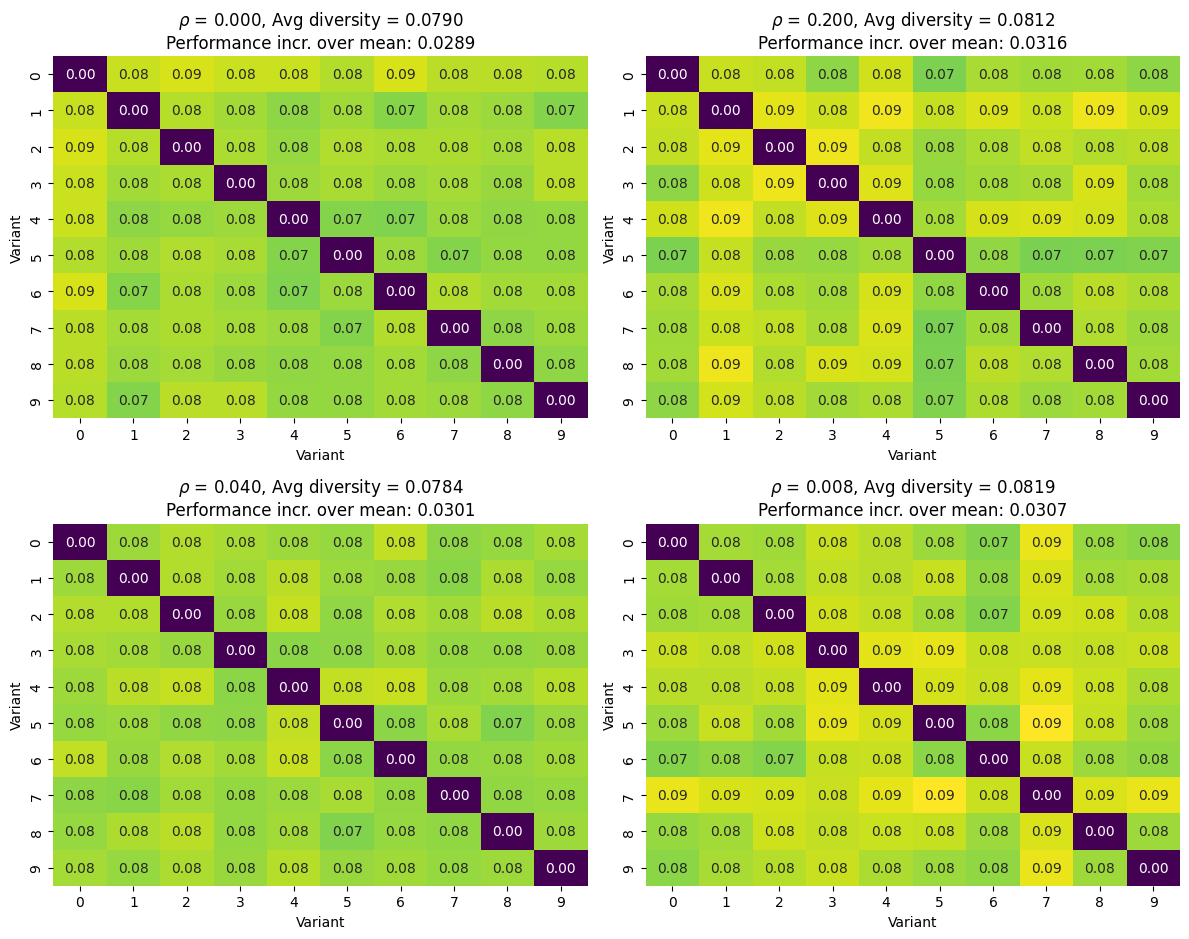

Figure saved to correctness_disagreement_grid.png


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
import numpy as np

# Plot the 'correctness_disagreement' matrix for the first four ensembles in a 2x2 grid, no colorbar
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Prepare all matrices and set global vmin/vmax for consistent color scaling
all_matrices = [df[i, "pairwise_correctness_disagreement"] for i in range(4)]
all_arrays = [
    (
        torch.tensor(m).cpu().numpy()
        if not isinstance(m, torch.Tensor)
        else m.cpu().numpy()
    )
    for m in all_matrices
]
vmin = np.min([a.min() for a in all_arrays])
vmax = np.max([a.max() for a in all_arrays])

for i in range(4):
    matrix = all_arrays[i]
    ax = axes[i]
    # Get the increase in performance for this ensemble
    acc_diff = df[i, "accuracy_diff"]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        ax=ax,
        cbar=False,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(
        f'$\\rho$ = {df[i, "rho"]:.3f}, Avg diversity = {df[i, "correctness_disagreement"]:.4f}\nPerformance incr. over mean: {acc_diff:.4f}'
    )
    ax.set_xlabel("Variant")
    ax.set_ylabel("Variant")

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = (
    os.path.join(os.path.dirname(__file__), "correctness_disagreement_grid.png")
    if "__file__" in globals()
    else "correctness_disagreement_grid.png"
)
plt.savefig(fig_path, dpi=200)
plt.show()
print(f"Figure saved to {fig_path}")